**Reinforcement Learning with Q-Learning & Policy Optimization**

This implementation focuses on implementing two core techniques of Reinforcement Learning — Q-Learning and Policy Optimization (REINFORCE) — using the CartPole-v1 environment from Gymnasium. Reinforcement Learning is a type of machine learning where an agent learns to make decisions by interacting with an environment and receiving feedback in the form of rewards or penalties. The goal is to develop a policy that maximizes the cumulative reward over time through trial and error. In this notebook, we perform a complete workflow starting from understanding the environment and exploring its state space through Exploratory Data Analysis (EDA), to implementing and training two different types of algorithms. Q-Learning, a value-based method, estimates the best action for each state using a Q-table and the Bellman equation, while Policy Optimization, a policy-based method, directly learns the action probabilities using a neural network optimized through gradient ascent. Both methods are trained, evaluated, and compared to understand their strengths and limitations. This project provides a practical demonstration of how reinforcement learning agents can learn optimal strategies through continuous interaction with their environment.

In [1]:
# Import Libraries
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import joblib


In [2]:
# Environment Initialization
env = gym.make("CartPole-v1")
state, _ = env.reset()
print("State space:", env.observation_space)
print("Action space:", env.action_space)

State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


In [3]:
# Exploratory Data Analysis (EDA)
sample_states = []
sample_actions = []
sample_rewards = []

for _ in range(1000):
    action = env.action_space.sample()
    next_state, reward, done, truncated, _ = env.step(action)
    sample_states.append(next_state)
    sample_actions.append(action)
    sample_rewards.append(reward)
    if done or truncated:
        env.reset()

sample_states = np.array(sample_states)


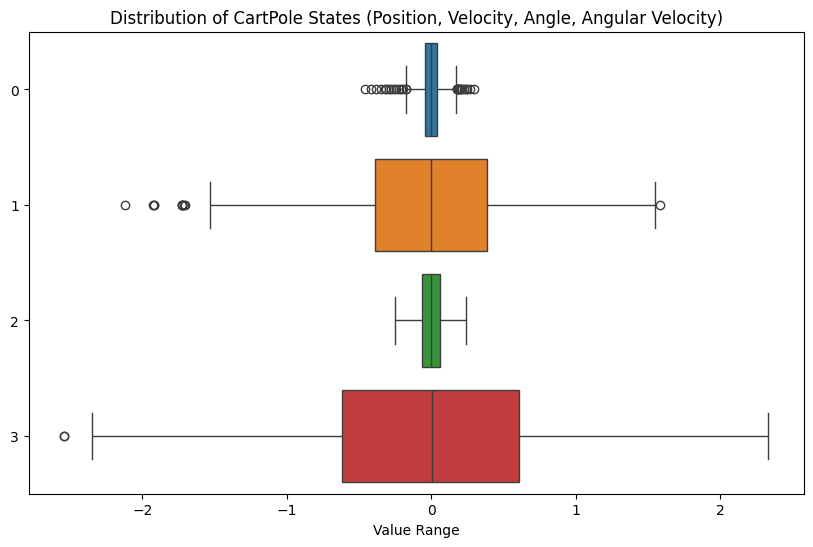

In [4]:
# Visualize State Distributions
plt.figure(figsize=(10,6))
sns.boxplot(data=sample_states, orient="h")
plt.title("Distribution of CartPole States (Position, Velocity, Angle, Angular Velocity)")
plt.xlabel("Value Range")
plt.show()

In [6]:
# Data Preprocessing (State Discretization for Q-Learning)
n_bins = 6
state_bins = [
    np.linspace(-4.8, 4.8, n_bins),
    np.linspace(-5, 5, n_bins),
    np.linspace(-0.418, 0.418, n_bins),
    np.linspace(-5, 5, n_bins)
]

def discretize_state(state):
    return tuple(np.digitize(s, bins) for s, bins in zip(state, state_bins))

n_actions = env.action_space.n
Q = np.zeros([n_bins+1, n_bins+1, n_bins+1, n_bins+1, n_actions])


In [8]:
# Q-Learning Algorithm Implementation
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
episodes = 5000
max_steps = 200
rewards = []


In [10]:
for episode in range(episodes):
    state, _ = env.reset()
    state_disc = discretize_state(state)
    total_reward = 0

    for step in range(max_steps):
        # ε-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state_disc])

        next_state, reward, done, truncated, _ = env.step(action)
        next_state_disc = discretize_state(next_state)
        total_reward += reward

        # Q-learning update
        Q[state_disc + (action,)] += alpha * (
            reward + gamma * np.max(Q[next_state_disc]) - Q[state_disc + (action,)]
        )

        state_disc = next_state_disc
        if done or truncated:
            break

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards.append(total_reward)

print("Training completed ")


Training completed 


In [12]:
# ave Trained Model
joblib.dump(Q, "Q_Learning_CartPole.pkl")


['Q_Learning_CartPole.pkl']

**Policy Optimization (Policy Gradient) Implementation**

In [13]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=1)


In [14]:
# Define Helper Functions
def select_action(policy, state):
    state = torch.FloatTensor(state).unsqueeze(0)
    probs = policy(state)
    dist = torch.distributions.Categorical(probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action)

def compute_returns(rewards, gamma=0.99):
    R = 0
    returns = []
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return returns


In [15]:
# Train with REINFORCE Algorithm
policy = PolicyNetwork(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

n_episodes = 1000
gamma = 0.99
reward_history = []

for episode in range(n_episodes):
    state, _ = env.reset()
    log_probs = []
    rewards = []
    total_reward = 0
    done = False

    while not done:
        action, log_prob = select_action(policy, state)
        next_state, reward, done, truncated, _ = env.step(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        state = next_state
        total_reward += reward

        if done or truncated:
            returns = compute_returns(rewards, gamma)
            returns = torch.tensor(returns)
            loss = -torch.sum(torch.stack(log_probs) * (returns - returns.mean()))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    reward_history.append(total_reward)
    if episode % 50 == 0:
        print(f"Episode {episode} → Total Reward: {total_reward}")


Episode 0 → Total Reward: 14.0
Episode 50 → Total Reward: 12.0
Episode 100 → Total Reward: 20.0
Episode 150 → Total Reward: 13.0
Episode 200 → Total Reward: 10.0
Episode 250 → Total Reward: 14.0
Episode 300 → Total Reward: 10.0
Episode 350 → Total Reward: 10.0
Episode 400 → Total Reward: 18.0
Episode 450 → Total Reward: 10.0
Episode 500 → Total Reward: 10.0
Episode 550 → Total Reward: 12.0
Episode 600 → Total Reward: 10.0
Episode 650 → Total Reward: 9.0
Episode 700 → Total Reward: 9.0
Episode 750 → Total Reward: 10.0
Episode 800 → Total Reward: 9.0
Episode 850 → Total Reward: 9.0
Episode 900 → Total Reward: 9.0
Episode 950 → Total Reward: 8.0


In [16]:
# Save train Model
torch.save(policy.state_dict(), "Policy_Gradient_CartPole.pth")


**Conclusion:-**

In conclusion, this implementation successfully demonstrated the implementation and comparison of two foundational Reinforcement Learning algorithms — Q-Learning and Policy Optimization (REINFORCE) — using the CartPole-v1 environment. Through continuous interaction with the environment, both algorithms learned to balance the pole effectively, showcasing how agents can improve decision-making through experience and feedback. The Q-Learning approach, being value-based, relied on a discretized state space and iteratively updated a Q-table to estimate optimal actions. In contrast, the Policy Gradient method directly optimized a neural network-based policy to determine the probability distribution over actions, allowing it to handle continuous state spaces more flexibly.

From the experiments, Q-Learning proved to be simpler and faster for small, discrete problems, while Policy Optimization demonstrated greater scalability and adaptability for more complex environments. Overall, this project highlights the fundamental difference between value-based and policy-based reinforcement learning methods — both aiming to maximize long-term rewards but employing distinct learning strategies. It serves as a solid foundation for advancing toward more sophisticated deep reinforcement learning algorithms such as Deep Q-Networks (DQN), A2C, or PPO in future projects.